# データサイエンス特論 第10回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2, f_regression, mutual_info_regression, r_regression


## 主成分分析

#### 演習問題1の回答

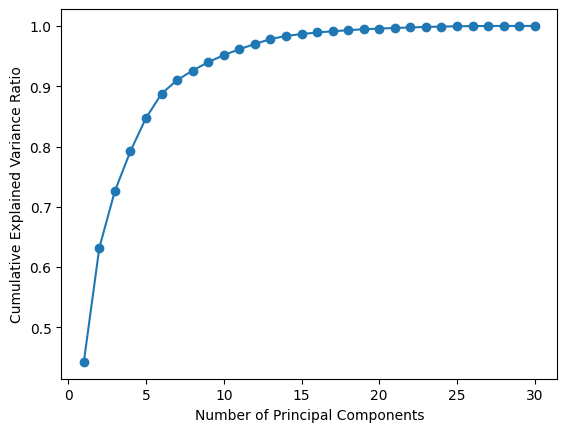

In [63]:
# 乳がんデータセットの読み込み
data = load_breast_cancer()
breast_df = pd.DataFrame(data.data, columns=data.feature_names)

# PCAの標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(breast_df)

# PCAの適用
pca = PCA()
pca.fit(X_scaled)

# 各主成分の寄与率と累積寄与率を計算
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# 描画
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.show()

- 15~20個の属性でほとんど1に近付いている。
- 半分くらい属性を削減できるのではと考える。

#### 演習問題2の回答

In [64]:
# 累積寄与率が95%を超える最小の主成分数を求める
n_components = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"累積寄与率95%以上を満たす主成分の数: {n_components}")
print(f"そのときの累積寄与率: {cumulative_variance_ratio[n_components - 1]:.4f}")

# 求めた主成分数でPCAを適用
pca_reduced = PCA(n_components=n_components)
X_reduced = pca_reduced.fit_transform(X_scaled)

# データフレームの作成
breast_reduced_df = pd.DataFrame(X_reduced,columns=[f"PC{i}" for i in range(1, n_components + 1)])

print(f"変換前の形状: {X_scaled.shape}")
print(f"変換後の形状: {X_reduced.shape}")
breast_reduced_df.head()

累積寄与率95%以上を満たす主成分の数: 10
そのときの累積寄与率: 0.9516
変換前の形状: (569, 30)
変換後の形状: (569, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704


- PCAを用いて属性を減らすことに成功した。

## 属性選択

#### 演習問題3の回答

In [65]:
y = data.target

# ANOVA F値
skb_f = SelectKBest(score_func=f_classif, k=3).fit(breast_df, y)
features_f = breast_df.columns[skb_f.get_support()].tolist()
print("f_classif:", features_f)

# 相互情報量
skb_mi = SelectKBest(score_func=mutual_info_classif, k=3).fit(breast_df, y)
features_mi = breast_df.columns[skb_mi.get_support()].tolist()
print("mutual_info_classif:", features_mi)

# カイ二乗検定
X_minmax = MinMaxScaler().fit_transform(breast_df)
skb_chi2 = SelectKBest(score_func=chi2, k=3).fit(X_minmax, y)
features_chi2 = breast_df.columns[skb_chi2.get_support()].tolist()
print("chi2:", features_chi2)

f_classif: ['mean concave points', 'worst perimeter', 'worst concave points']
mutual_info_classif: ['worst radius', 'worst perimeter', 'worst area']
chi2: ['mean concavity', 'mean concave points', 'worst concave points']


- 属性の選択結果は同一にならない。

#### 演習問題4の回答

In [66]:
# 糖尿病データセットの読み込み
diabetes_data = load_diabetes()
diabetes_df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)

In [67]:
y = diabetes_data.target

# F値
skb_f = SelectKBest(score_func=f_regression, k=3).fit(diabetes_df, y)
features_f = diabetes_df.columns[skb_f.get_support()].tolist()
print("f_regression:", features_f)

# 相互情報量
skb_mi = SelectKBest(score_func=mutual_info_regression, k=3).fit(diabetes_df, y)
features_mi = diabetes_df.columns[skb_mi.get_support()].tolist()
print("mutual_info_regression:", features_mi)

# ピアソン相関係数
skb_r = SelectKBest(score_func=r_regression, k=3).fit(diabetes_df, y)
features_r = diabetes_df.columns[skb_r.get_support()].tolist()
print("r_regression:", features_r)


f_regression: ['bmi', 'bp', 's5']
mutual_info_regression: ['bmi', 's5', 's6']
r_regression: ['bmi', 'bp', 's5']


- F値とピアソン相関係数では同じ属性選択になった。
- bmiとs5は３つで共通している。